In [60]:
#!pip install pandas matplotlib jiwer

In [100]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from jiwer import wer, cer
import numpy as np

# All models

In [101]:
gold_dir = "Others/English_dataset/gold_english"

model_dirs = {
    "GPT-5.4": "Others/English_dataset/gpt_with_english_dataset/outputs/Experiment_1",
    "Gemini 3.1 Pro": "Others/English_dataset/gemini_with_english_dataset/outputs/Experiment_1",
    "Qwen": "Others/English_dataset/qwen_with_english_dataset/outputs/Experiment_1",
    "PaddleOCR-VL 1.5": "Others/English_dataset/paddleOCR_vl_1.5_with_english_dataset/outputs/Experiment_1",
    "PaddleOCR": "Others/English_dataset/paddleOCR_english_dataset/outputs/Experiment_1",
    "EasyOCR": "Others/English_dataset/easyocr_with_english_dataset/outputs/Experiment_1",
    "Tesseract": "Others/English_dataset/pytesseract_english_dataset/outputs/Experiment_1"
}

pages = range(1, 7)

In [102]:
output_dir = "Others/English_dataset/resultsOfAllModel_en"
os.makedirs(output_dir, exist_ok=True)

print("Output directory:", output_dir)

Output directory: Others/English_dataset/resultsOfAllModel_en


In [103]:
def normalize_text(text):
    text = text.lower()
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    return text

In [104]:
import unicodedata

def normalize_text_paddlevl(text):

    text = unicodedata.normalize("NFC", text)
    text = text.lower()

    # normalize apostrophes
    text = text.replace("’", "'")
    text = text.replace("‘", "'")
    text = text.replace("´", "'")
    text = text.replace("`", "'")

    # normalize quotation marks
    text = text.replace("“", '"')
    text = text.replace("”", '"')

    # join words split by line-ending hyphens
    text = re.sub(
        r"(\w)-[ \t]*\r?\n[ \t]*(\w)",
        r"\1\2",
        text
    )

    # normalize whitespace
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [66]:
results = []

for model, output_dir in model_dirs.items():
    for page in pages:
        with open(f"{gold_dir}/{page}.txt", encoding="utf-8") as f:
            gold_text = f.read()

        with open(f"{output_dir}/page_{page}.txt", encoding="utf-8") as f:
            prediction_text = f.read()

        if model == "PaddleOCR-VL 1.5":
            gold = normalize_text_paddlevl(gold_text)
            prediction = normalize_text_paddlevl(prediction_text)
        else:
            gold = normalize_text(gold_text)
            prediction = normalize_text(prediction_text)

        results.append({
            "Model": model,
            "Page": page,
            "WER": wer(gold, prediction),
            "CER": cer(gold, prediction)
        })

In [105]:
df = pd.DataFrame(results)
#df

# Experiment-1

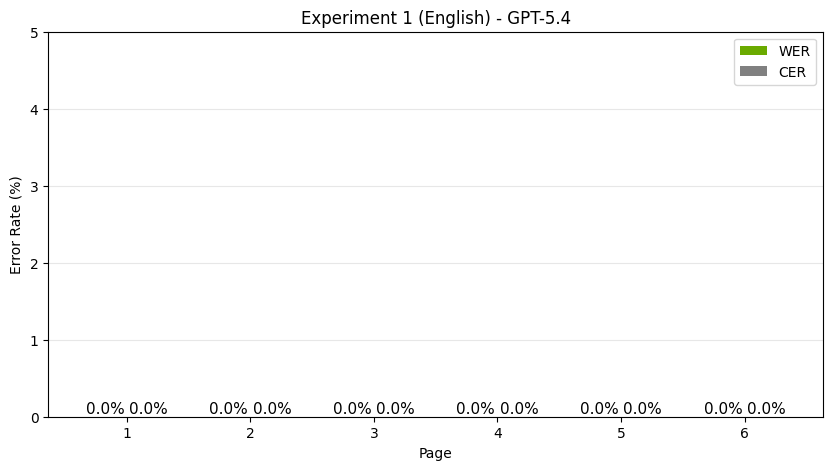

In [106]:
df_gpt = df[df["Model"] == "GPT-5.4"]

x = np.arange(len(df_gpt))
width = 0.35

plt.figure(figsize=(10, 5))

bars1 = plt.bar(
    x - width/2,
    df_gpt["WER"] * 100,
    width,
    label="WER",
    color="#6AAA00"
)

bars2 = plt.bar(
    x + width/2,
    df_gpt["CER"] * 100,
    width,
    label="CER",
    color="#808080"
)

for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():.1f}%",
            ha="center",
            va="bottom",
            fontsize=11
        )

plt.xticks(x, df_gpt["Page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 1 (English) - GPT-5.4")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.ylim(0, 5)
plt.yticks(np.arange(0, 6, 1))

save_path = os.path.join(
    output_dir,
    "experiment_1_gpt_graph_english.pdf"
)

plt.savefig(
    save_path,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

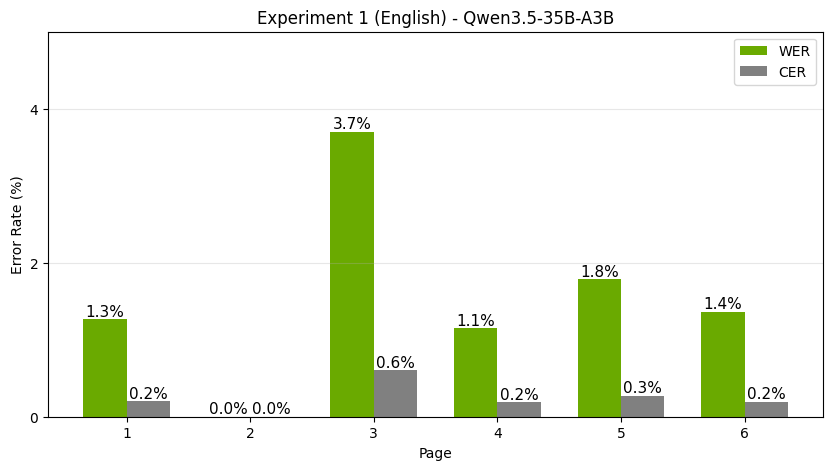

In [107]:
df_qwen = df[df["Model"] == "Qwen"]

x = np.arange(len(df_qwen))
width = 0.35

plt.figure(figsize=(10, 5))

bars1 = plt.bar(
    x - width/2,
    df_qwen["WER"] * 100,
    width,
    label="WER",
    color="#6AAA00"
)

bars2 = plt.bar(
    x + width/2,
    df_qwen["CER"] * 100,
    width,
    label="CER",
    color="#808080"
)

for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():.1f}%",
            ha="center",
            va="bottom",
            fontsize=11
        )

plt.xticks(x, df_qwen["Page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 1 (English) - Qwen3.5-35B-A3B")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.ylim(0, 5)
plt.yticks(np.arange(0, 6, 2))

save_path = os.path.join(
    output_dir,
    "experiment_1_qwen_graph_english.pdf"
)

plt.savefig(
    save_path,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

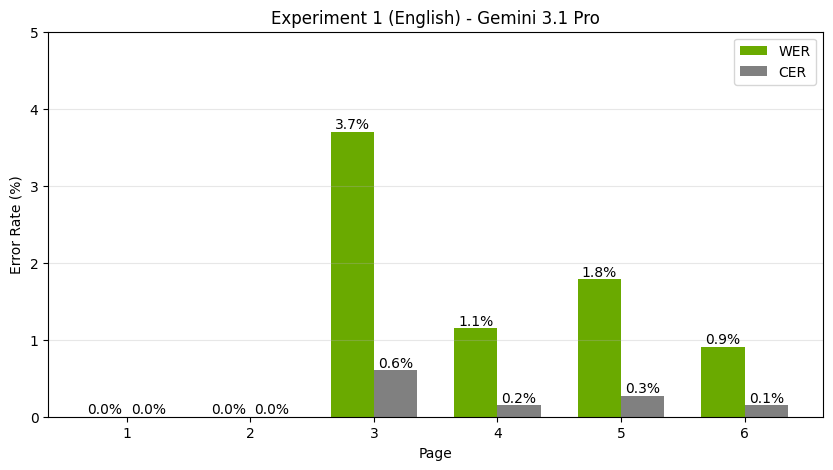

In [108]:
df_gemini = df[df["Model"] == "Gemini 3.1 Pro"]

x = np.arange(len(df_gemini))
width = 0.35

plt.figure(figsize=(10, 5))

bars1 = plt.bar(
    x - width/2,
    df_gemini["WER"] * 100,
    width,
    label="WER",
    color="#6AAA00"
)

bars2 = plt.bar(
    x + width/2,
    df_gemini["CER"] * 100,
    width,
    label="CER",
    color="#808080"
)

for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():.1f}%",
            ha="center",
            va="bottom",
            fontsize=10
        )

plt.xticks(x, df_gemini["Page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 1 (English) - Gemini 3.1 Pro")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.ylim(0, 5)
plt.yticks(np.arange(0, 6, 1))

save_path = os.path.join(
    output_dir,
    "experiment_1_gemini_graph_english.pdf"
)

plt.savefig(
    save_path,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

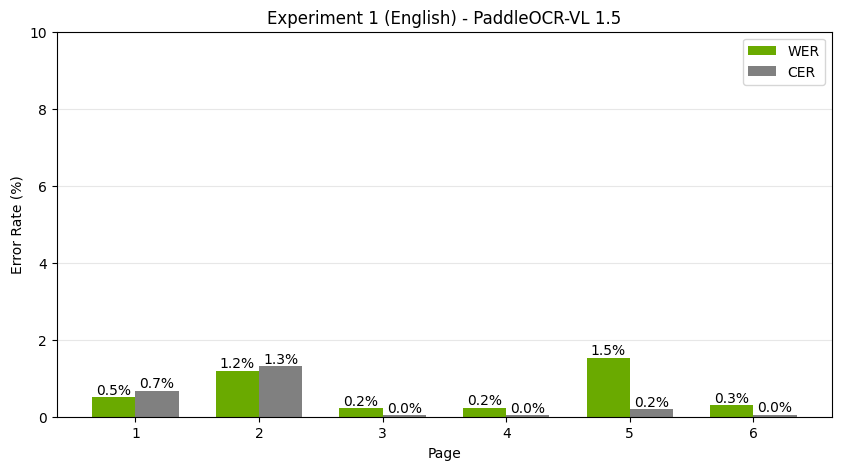

In [109]:
df_paddlevl = df[df["Model"] == "PaddleOCR-VL 1.5"]

x = np.arange(len(df_paddlevl))
width = 0.35

plt.figure(figsize=(10, 5))

bars1 = plt.bar(
    x - width/2,
    df_paddlevl["WER"] * 100,
    width,
    label="WER",
    color="#6AAA00"
)

bars2 = plt.bar(
    x + width/2,
    df_paddlevl["CER"] * 100,
    width,
    label="CER",
    color="#808080"
)

for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():.1f}%",
            ha="center",
            va="bottom",
            fontsize=10
        )

plt.xticks(x, df_paddlevl["Page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 1 (English) - PaddleOCR-VL 1.5")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.ylim(0, 10)
plt.yticks(np.arange(0, 11, 2))

save_path = os.path.join(
    output_dir,
    "experiment_1_paddlevl_graph_english.pdf"
)

plt.savefig(
    save_path,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

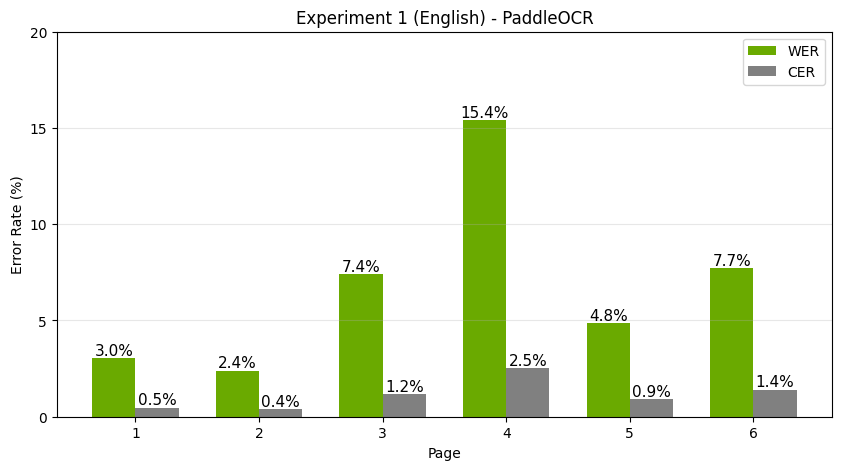

In [110]:
df_paddle = df[df["Model"] == "PaddleOCR"]

x = np.arange(len(df_paddle))
width = 0.35

plt.figure(figsize=(10, 5))

bars1 = plt.bar(
    x - width/2,
    df_paddle["WER"] * 100,
    width,
    label="WER",
    color="#6AAA00"
)

bars2 = plt.bar(
    x + width/2,
    df_paddle["CER"] * 100,
    width,
    label="CER",
    color="#808080"
)

for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():.1f}%",
            ha="center",
            va="bottom",
            fontsize=11
        )

plt.xticks(x, df_paddle["Page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 1 (English) - PaddleOCR")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.ylim(0, 20)
plt.yticks(np.arange(0, 21, 5))

save_path = os.path.join(
    output_dir,
    "experiment_1_paddleocr_graph_english.pdf"
)

plt.savefig(
    save_path,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

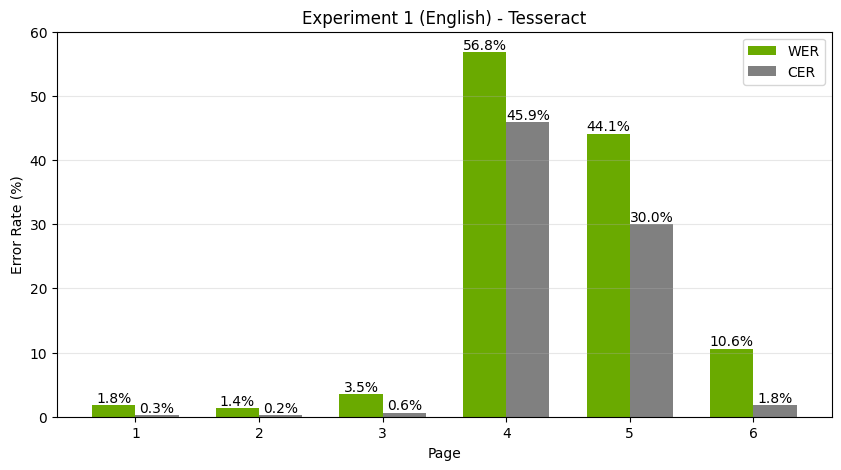

In [111]:
df_tesseract = df[df["Model"] == "Tesseract"]

x = np.arange(len(df_tesseract))
width = 0.35

plt.figure(figsize=(10, 5))

bars1 = plt.bar(
    x - width/2,
    df_tesseract["WER"] * 100,
    width,
    label="WER",
    color="#6AAA00"
)

bars2 = plt.bar(
    x + width/2,
    df_tesseract["CER"] * 100,
    width,
    label="CER",
    color="#808080"
)

for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():.1f}%",
            ha="center",
            va="bottom",
            fontsize=10
        )

plt.xticks(x, df_tesseract["Page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 1 (English) - Tesseract")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.ylim(0, 60)
plt.yticks(np.arange(0, 61, 10))

save_path = os.path.join(
    output_dir,
    "experiment_1_pytesseract_graph_english.pdf"
)

plt.savefig(
    save_path,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

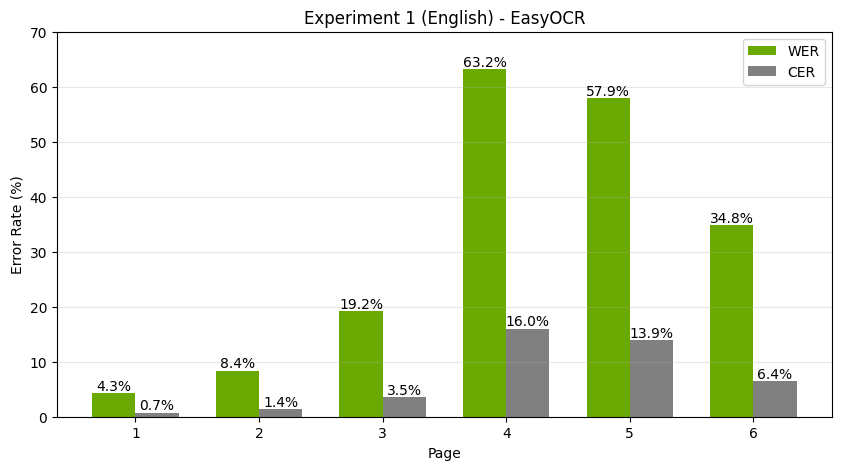

In [112]:
df_easyocr = df[df["Model"] == "EasyOCR"]

x = np.arange(len(df_easyocr))
width = 0.35

plt.figure(figsize=(10, 5))

bars1 = plt.bar(
    x - width/2,
    df_easyocr["WER"] * 100,
    width,
    label="WER",
    color="#6AAA00"
)

bars2 = plt.bar(
    x + width/2,
    df_easyocr["CER"] * 100,
    width,
    label="CER",
    color="#808080"
)

for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():.1f}%",
            ha="center",
            va="bottom",
            fontsize=10
        )

plt.xticks(x, df_easyocr["Page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 1 (English) - EasyOCR")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.ylim(0, 70)
plt.yticks(np.arange(0, 71, 10))

save_path = os.path.join(
    output_dir,
    "experiment_1_easyocr_graph_english.pdf"
)

plt.savefig(
    save_path,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

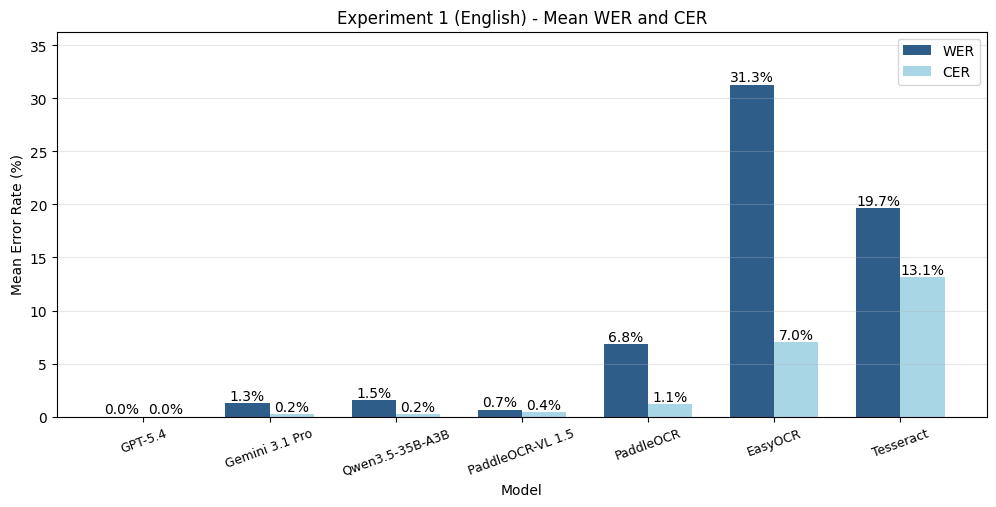

,Model,WER,CER
0,GPT-5.4,0.000000,0.000000
1,Gemini 3.1 Pro,0.012580,0.001956
2,Qwen,0.015453,0.002430
3,PaddleOCR-VL 1.5,0.006643,0.003828
4,PaddleOCR,0.068038,0.011449
5,EasyOCR,0.313063,0.069888
6,Tesseract,0.196917,0.131376


In [113]:
mean_df = df.groupby("Model")[["WER", "CER"]].mean().reset_index()

model_order = [
    "GPT-5.4",
    "Gemini 3.1 Pro",
    "Qwen",
    "PaddleOCR-VL 1.5",
    "PaddleOCR",
    "EasyOCR",
    "Tesseract"
]

mean_df["Model"] = pd.Categorical(
    mean_df["Model"],
    categories=model_order,
    ordered=True
)

mean_df = mean_df.sort_values("Model").reset_index(drop=True)

x = np.arange(len(mean_df))
width = 0.35

plt.figure(figsize=(12, 5))

bars1 = plt.bar(
    x - width/2,
    mean_df["WER"] * 100,
    width,
    label="WER",
    color="#2F5D8A"
)

bars2 = plt.bar(
    x + width/2,
    mean_df["CER"] * 100,
    width,
    label="CER",
    color="#A9D6E5"
)

for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():.1f}%",
            ha="center",
            va="bottom",
            fontsize=10
        )

plt.xticks(
    x,
    [
        "GPT-5.4",
        "Gemini 3.1 Pro",
        "Qwen3.5-35B-A3B",
        "PaddleOCR-VL 1.5",
        "PaddleOCR",
        "EasyOCR",
        "Tesseract"
    ],
    fontsize=9,
    rotation=20
)

plt.xlabel("Model")
plt.ylabel("Mean Error Rate (%)")
plt.title("Experiment 1 (English) - Mean WER and CER")
plt.legend()
plt.grid(axis="y", alpha=0.3)

max_value = max(
    mean_df["WER"].max(),
    mean_df["CER"].max()
) * 100

plt.ylim(0, max_value + 5)

save_path = os.path.join(
    output_dir,
    "experiment_1_all_models_mean_graph.pdf"
)

plt.savefig(
    save_path,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

mean_df

# Experiment-2

In [129]:
gold_dir = "Others/English_dataset/gold_english"

model_dirs_exp2 = {
    "GPT-5.4": "Others/English_dataset/gpt_with_english_dataset/outputs/Experiment_2",
    "Gemini 3.1 Pro": "Others/English_dataset/gemini_with_english_dataset/outputs/Experiment_2",
    "Qwen": "Others/English_dataset/qwen_with_english_dataset/outputs/Experiment_2",
    "PaddleOCR-VL 1.5": "Others/English_dataset/paddleOCR_vl_1.5_with_english_dataset/outputs/Experiment_2",
    "PaddleOCR": "Others/English_dataset/paddleOCR_english_dataset/outputs/Experiment_2",
    "EasyOCR": "Others/English_dataset/easyocr_with_english_dataset/outputs/Experiment_2",
    "Tesseract": "Others/English_dataset/pytesseract_english_dataset/outputs/Experiment_2"
}

pages = range(1, 7)

In [131]:
output_dir = "Others/English_dataset/resultsOfAllModel_en"
os.makedirs(output_dir, exist_ok=True)

print("Output directory:", output_dir)

Output directory: Others/English_dataset/resultsOfAllModel_en


In [132]:
results_exp2 = []

for model, model_output_dir in model_dirs_exp2.items():
    for page in pages:
        with open(f"{gold_dir}/{page}.txt", encoding="utf-8") as f:
            gold_text = f.read()

        with open(f"{model_output_dir}/page_{page}.txt", encoding="utf-8") as f:
            prediction_text = f.read()

        if model == "PaddleOCR-VL 1.5":
            gold = normalize_text_paddlevl(gold_text)
            prediction = normalize_text_paddlevl(prediction_text)
        else:
            gold = normalize_text(gold_text)
            prediction = normalize_text(prediction_text)

        results_exp2.append({
            "Model": model,
            "Page": page,
            "WER": wer(gold, prediction),
            "CER": cer(gold, prediction)
        })

In [133]:
df_exp2 = pd.DataFrame(results_exp2)
#df_exp2

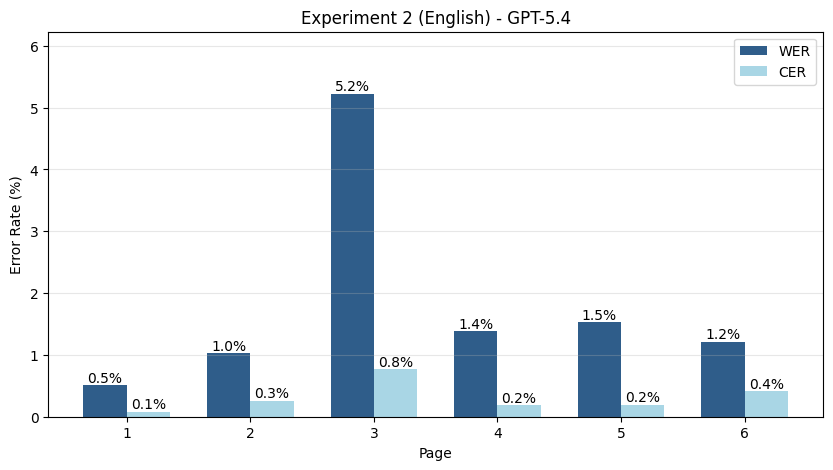

In [134]:
df_gpt_exp2 = df_exp2[df_exp2["Model"] == "GPT-5.4"]

x = np.arange(len(df_gpt_exp2))
width = 0.35

plt.figure(figsize=(10, 5))

bars1 = plt.bar(
    x - width/2,
    df_gpt_exp2["WER"] * 100,
    width,
    label="WER",
    color="#2F5D8A"
)

bars2 = plt.bar(
    x + width/2,
    df_gpt_exp2["CER"] * 100,
    width,
    label="CER",
    color="#A9D6E5"
)

for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():.1f}%",
            ha="center",
            va="bottom",
            fontsize=10
        )

plt.xticks(x, df_gpt_exp2["Page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 2 (English) - GPT-5.4")
plt.legend()
plt.grid(axis="y", alpha=0.3)

max_value = max(
    df_gpt_exp2["WER"].max(),
    df_gpt_exp2["CER"].max()
) * 100

plt.ylim(0, max_value + max(1, max_value * 0.15))

save_path = os.path.join(
    output_dir,
    "experiment_2_gpt_graph_english.pdf"
)

plt.savefig(save_path, format="pdf", bbox_inches="tight")
plt.show()

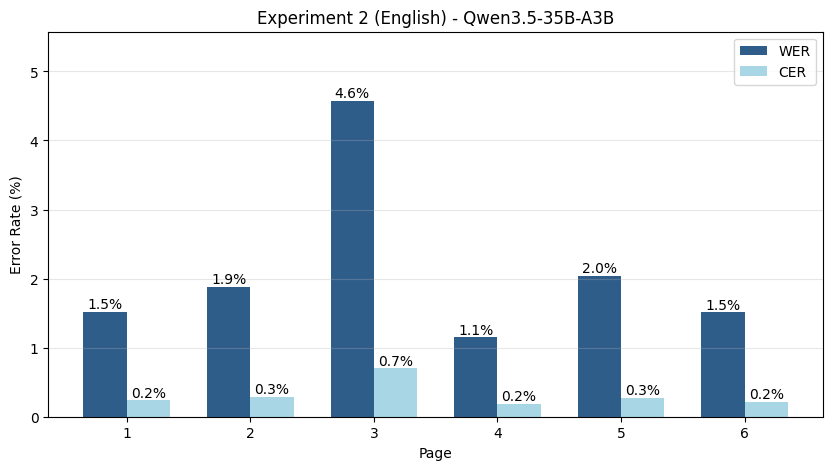

In [135]:
df_qwen_exp2 = df_exp2[df_exp2["Model"] == "Qwen"]

x = np.arange(len(df_qwen_exp2))
width = 0.35

plt.figure(figsize=(10, 5))

bars1 = plt.bar(
    x - width/2,
    df_qwen_exp2["WER"] * 100,
    width,
    label="WER",
    color="#2F5D8A"
)

bars2 = plt.bar(
    x + width/2,
    df_qwen_exp2["CER"] * 100,
    width,
    label="CER",
    color="#A9D6E5"
)

for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():.1f}%",
            ha="center",
            va="bottom",
            fontsize=10
        )

plt.xticks(x, df_qwen_exp2["Page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 2 (English) - Qwen3.5-35B-A3B")
plt.legend()
plt.grid(axis="y", alpha=0.3)

max_value = max(
    df_qwen_exp2["WER"].max(),
    df_qwen_exp2["CER"].max()
) * 100

plt.ylim(0, max_value + max(1, max_value * 0.15))

save_path = os.path.join(
    output_dir,
    "experiment_2_qwen_graph_english.pdf"
)

plt.savefig(save_path, format="pdf", bbox_inches="tight")
plt.show()

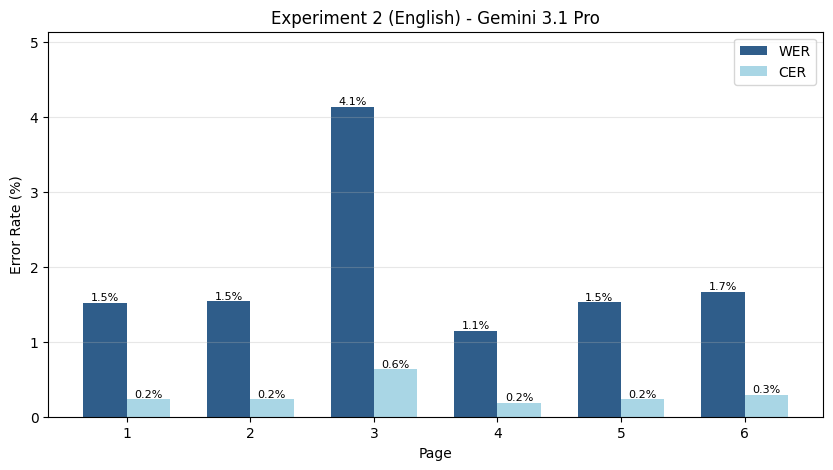

In [136]:
df_gemini_exp2 = df_exp2[df_exp2["Model"] == "Gemini 3.1 Pro"]

x = np.arange(len(df_gemini_exp2))
width = 0.35

plt.figure(figsize=(10, 5))

bars1 = plt.bar(
    x - width/2,
    df_gemini_exp2["WER"] * 100,
    width,
    label="WER",
    color="#2F5D8A"
)

bars2 = plt.bar(
    x + width/2,
    df_gemini_exp2["CER"] * 100,
    width,
    label="CER",
    color="#A9D6E5"
)

for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():.1f}%",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.xticks(x, df_gemini_exp2["Page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 2 (English) - Gemini 3.1 Pro")
plt.legend()
plt.grid(axis="y", alpha=0.3)

max_value = max(
    df_gemini_exp2["WER"].max(),
    df_gemini_exp2["CER"].max()
) * 100

plt.ylim(0, max_value + max(1, max_value * 0.15))

save_path = os.path.join(
    output_dir,
    "experiment_2_gemini_graph_english.pdf"
)

plt.savefig(save_path, format="pdf", bbox_inches="tight")
plt.show()

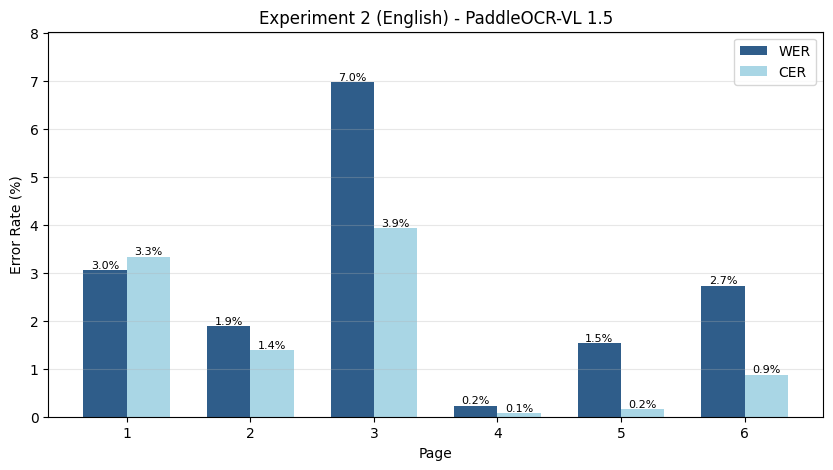

In [137]:
df_paddlevl_exp2 = df_exp2[df_exp2["Model"] == "PaddleOCR-VL 1.5"]

x = np.arange(len(df_paddlevl_exp2))
width = 0.35

plt.figure(figsize=(10, 5))

bars1 = plt.bar(
    x - width/2,
    df_paddlevl_exp2["WER"] * 100,
    width,
    label="WER",
    color="#2F5D8A"
)

bars2 = plt.bar(
    x + width/2,
    df_paddlevl_exp2["CER"] * 100,
    width,
    label="CER",
    color="#A9D6E5"
)

for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():.1f}%",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.xticks(x, df_paddlevl_exp2["Page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 2 (English) - PaddleOCR-VL 1.5")
plt.legend()
plt.grid(axis="y", alpha=0.3)

max_value = max(
    df_paddlevl_exp2["WER"].max(),
    df_paddlevl_exp2["CER"].max()
) * 100

plt.ylim(0, max_value + max(1, max_value * 0.15))

save_path = os.path.join(
    output_dir,
    "experiment_2_paddlevl_graph_english.pdf"
)

plt.savefig(save_path, format="pdf", bbox_inches="tight")
plt.show()

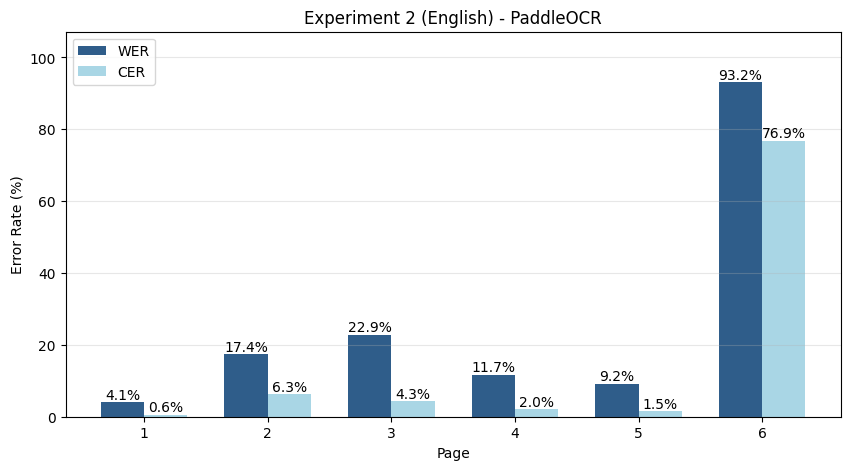

In [138]:
df_paddle_exp2 = df_exp2[df_exp2["Model"] == "PaddleOCR"]

x = np.arange(len(df_paddle_exp2))
width = 0.35

plt.figure(figsize=(10, 5))

bars1 = plt.bar(
    x - width/2,
    df_paddle_exp2["WER"] * 100,
    width,
    label="WER",
    color="#2F5D8A"
)

bars2 = plt.bar(
    x + width/2,
    df_paddle_exp2["CER"] * 100,
    width,
    label="CER",
    color="#A9D6E5"
)

for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():.1f}%",
            ha="center",
            va="bottom",
            fontsize=10
        )

plt.xticks(x, df_paddle_exp2["Page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 2 (English) - PaddleOCR")
plt.legend()
plt.grid(axis="y", alpha=0.3)

max_value = max(
    df_paddle_exp2["WER"].max(),
    df_paddle_exp2["CER"].max()
) * 100

plt.ylim(0, max_value + max(1, max_value * 0.15))

save_path = os.path.join(
    output_dir,
    "experiment_2_paddleocr_graph_english.pdf"
)

plt.savefig(save_path, format="pdf", bbox_inches="tight")
plt.show()

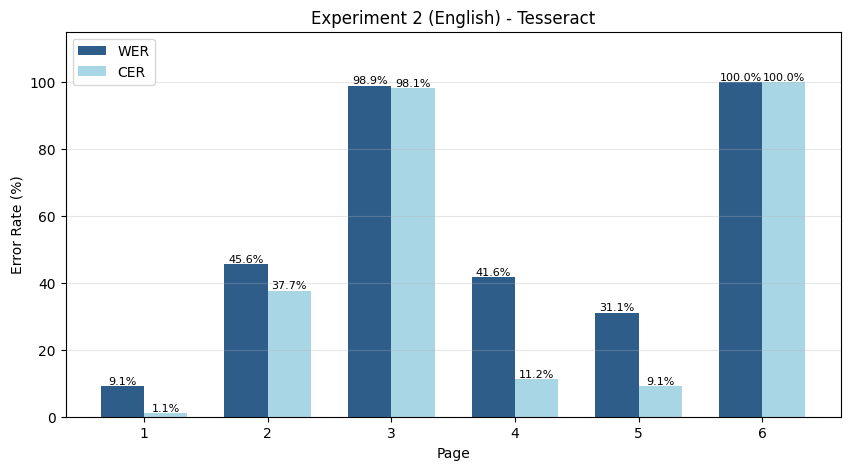

In [139]:
df_tesseract_exp2 = df_exp2[df_exp2["Model"] == "Tesseract"]

x = np.arange(len(df_tesseract_exp2))
width = 0.35

plt.figure(figsize=(10, 5))

bars1 = plt.bar(
    x - width/2,
    df_tesseract_exp2["WER"] * 100,
    width,
    label="WER",
    color="#2F5D8A"
)

bars2 = plt.bar(
    x + width/2,
    df_tesseract_exp2["CER"] * 100,
    width,
    label="CER",
    color="#A9D6E5"
)

for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():.1f}%",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.xticks(x, df_tesseract_exp2["Page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 2 (English) - Tesseract")
plt.legend()
plt.grid(axis="y", alpha=0.3)

max_value = max(
    df_tesseract_exp2["WER"].max(),
    df_tesseract_exp2["CER"].max()
) * 100

plt.ylim(0, max_value + max(1, max_value * 0.15))

save_path = os.path.join(
    output_dir,
    "experiment_2_pytesseract_graph_english.pdf"
)

plt.savefig(save_path, format="pdf", bbox_inches="tight")
plt.show()

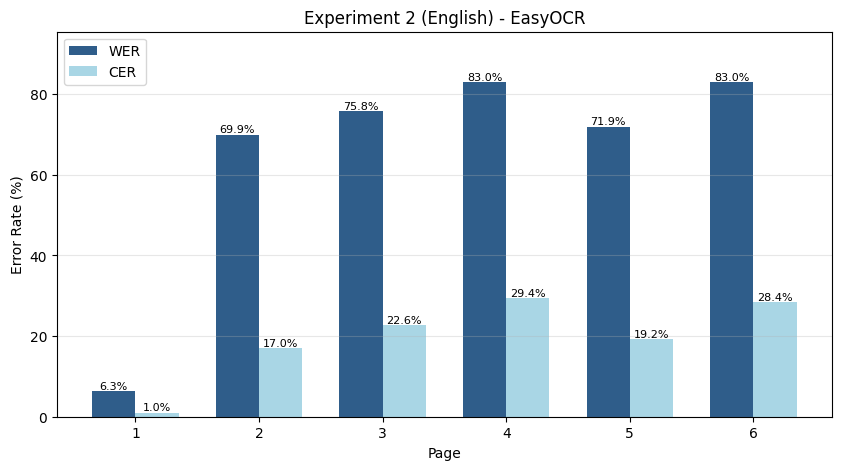

In [142]:
df_easyocr_exp2 = df_exp2[df_exp2["Model"] == "EasyOCR"]

x = np.arange(len(df_easyocr_exp2))
width = 0.35

plt.figure(figsize=(10, 5))

bars1 = plt.bar(
    x - width/2,
    df_easyocr_exp2["WER"] * 100,
    width,
    label="WER",
    color="#2F5D8A"
)

bars2 = plt.bar(
    x + width/2,
    df_easyocr_exp2["CER"] * 100,
    width,
    label="CER",
    color="#A9D6E5"
)

for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():.1f}%",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.xticks(x, df_easyocr_exp2["Page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 2 (English) - EasyOCR")
plt.legend()
plt.grid(axis="y", alpha=0.3)

max_value = max(
    df_easyocr_exp2["WER"].max(),
    df_easyocr_exp2["CER"].max()
) * 100

plt.ylim(0, max_value + max(1, max_value * 0.15))

save_path = os.path.join(
    output_dir,
    "experiment_2_easyocr_graph_english.pdf"
)

plt.savefig(save_path, format="pdf", bbox_inches="tight")
plt.show()

In [140]:
mean_exp2 = (
    df_exp2
    .groupby("Model")[["WER", "CER"]]
    .mean()
    .reset_index()
)

mean_exp2

,Model,WER,CER
0,EasyOCR,0.650057,0.195978
1,GPT-5.4,0.018140,0.003183
2,Gemini 3.1 Pro,0.019246,0.003042
3,PaddleOCR,0.264104,0.152667
4,PaddleOCR-VL 1.5,0.027316,0.016257
5,Qwen,0.021140,0.003184
6,Tesseract,0.544034,0.428632


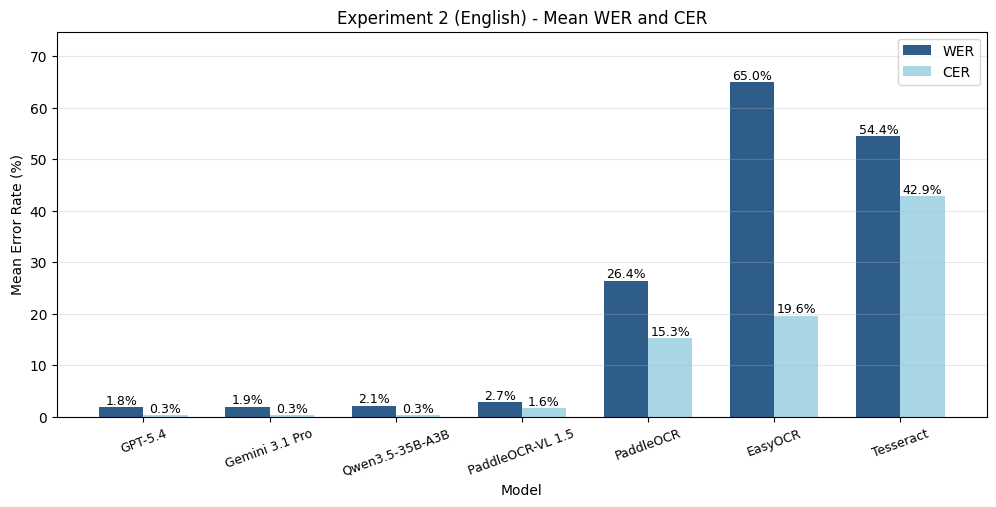

,Model,WER,CER
0,GPT-5.4,0.018140,0.003183
1,Gemini 3.1 Pro,0.019246,0.003042
2,Qwen,0.021140,0.003184
3,PaddleOCR-VL 1.5,0.027316,0.016257
4,PaddleOCR,0.264104,0.152667
5,EasyOCR,0.650057,0.195978
6,Tesseract,0.544034,0.428632


In [141]:
model_order = [
    "GPT-5.4",
    "Gemini 3.1 Pro",
    "Qwen",
    "PaddleOCR-VL 1.5",
    "PaddleOCR",
    "EasyOCR",
    "Tesseract"
]

mean_exp2["Model"] = pd.Categorical(
    mean_exp2["Model"],
    categories=model_order,
    ordered=True
)

mean_exp2 = mean_exp2.sort_values("Model").reset_index(drop=True)

x = np.arange(len(mean_exp2))
width = 0.35

plt.figure(figsize=(12, 5))

bars1 = plt.bar(
    x - width/2,
    mean_exp2["WER"] * 100,
    width,
    label="WER",
    color="#2F5D8A"
)

bars2 = plt.bar(
    x + width/2,
    mean_exp2["CER"] * 100,
    width,
    label="CER",
    color="#A9D6E5"
)

for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.xticks(
    x,
    [
        "GPT-5.4",
        "Gemini 3.1 Pro",
        "Qwen3.5-35B-A3B",
        "PaddleOCR-VL 1.5",
        "PaddleOCR",
        "EasyOCR",
        "Tesseract"
    ],
    fontsize=9,
    rotation=20
)

plt.xlabel("Model")
plt.ylabel("Mean Error Rate (%)")
plt.title("Experiment 2 (English) - Mean WER and CER")
plt.legend()
plt.grid(axis="y", alpha=0.3)

max_value = max(
    mean_exp2["WER"].max(),
    mean_exp2["CER"].max()
) * 100

plt.ylim(0, max_value + max(1, max_value * 0.15))

save_path = os.path.join(
    output_dir,
    "experiment_2_all_models_mean_graph.pdf"
)

plt.savefig(
    save_path,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

mean_exp2